[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab5-Comp-Mod/notebooks/07-cybernetics-of-wound-healing.ipynb)

# 07-cybernetics-of-wound-healing

_Arvid Lundervold w/Claude 2026-02-14_

Update: 2026-02-15

- https://royalsocietypublishing.org/doi/10.1098/rsif.2021.0497 (A feedback control architecture for bioelectronic devices with applications to wound healing)
- https://ieeexplore.ieee.org/document/8191999 (Wound healing as an electromechanical feedback control system)
- https://www.biorxiv.org/content/10.1101/659714v2 (Bacterial Controller Aided Wound Healing)

7. **Cybernetics of Wound Healing**

i. Motivation:
- Understanding wound healing as a feedback control system
- Distinguishing acute vs chronic wounds
- Bioelectronic interventions for accelerated healing
- Synthetic biology controllers (e.g., bacterial IFFL)

AI support: Generate explanatory content about control theory in biology, create analogies between engineering and physiological feedback loops.

ii. Conceptual/Mathematical Description:
- Dynamical population models (inflammatory cells, fibroblasts, etc.)
- Feedback loops in the healing cascade
- Bistable phenomenological models
- ODEs for wound area and cell populations

AI support: Break down control-theoretic concepts, generate step-by-step derivations, create visual explanations of feedback structure.

iii. Implementation:
- ODE integration (SciPy)
- State variables for wound state and cell populations
- Control-theoretic parameters (gain, time constants)

AI support: Debug code, suggest optimizations, explain numerical integration methods.

iv. Simulation/Visualization:
- Wound closure over time
- Phase portraits
- Parameter sensitivity analysis
- Interactive healing curves

AI support: Generate efficient plotting code, suggest best visualization practices, create interactive dashboards.

v. Going Deeper:
- Bioelectronic control architectures
- Bacterial controllers with incoherent feed-forward loops (IFFL)
- Spatial models of wound healing
- Chronic wound dynamics

AI support: Suggest relevant research papers, generate code templates for extensions, help optimize complex simulations.

----

The project can be implemented with varying levels of complexity, making it suitable for different skill levels. Key Python libraries to use include:

- NumPy/SciPy for numerical computations
- Matplotlib/Plotly for visualization
- NetworkX for network analysis
- Pandas for data management
- SymPy for symbolic mathematics
- scikit-learn for machine learning components

AI can significantly enhance the learning experience by:
1. Generating explanatory content and tutorials
2. Helping with code implementation and debugging
3. Suggesting optimizations and best practices
4. Finding relevant literature and examples
5. Creating interactive visualization tools
6. Assisting with parameter optimization
7. Generating test cases and validation data
8. Helping with model extension and modification


# Cybernetics of Wound Healing: A Feedback Control Perspective

This tutorial implements a simple dynamical model of wound healing, viewed through the lens of cybernetics and feedback control. Wound healing involves a cascade of cellular events (inflammation, proliferation, remodeling) that can be modeled as a feedback control system.

## Mathematical Introduction to Wound Healing Dynamics

### Simple Phenomenological Model

A minimal model describes wound area $A(t)$ with exponential closure:

$$ \frac{dA}{dt} = -k \cdot A $$

where $k$ is the healing rate constant. This yields $A(t) = A_0 e^{-kt}$.

### Feedback-Enhanced Model

A cybernetic extension adds a "healing factor" $F$ (e.g., fibroblast activity) that is stimulated by the wound and feeds back to accelerate closure:

$$ \frac{dA}{dt} = -k \cdot A \cdot (1 + \alpha F) $$

$$ \frac{dF}{dt} = \beta A - \gamma F $$

where:
- $\alpha$: feedback gain (how much $F$ accelerates healing)
- $\beta$: wound-stimulated recruitment of healing factors
- $\gamma$: natural decay of healing factors

This forms a **negative feedback loop**: wound → stimulates $F$ → $F$ accelerates wound closure → wound shrinks.

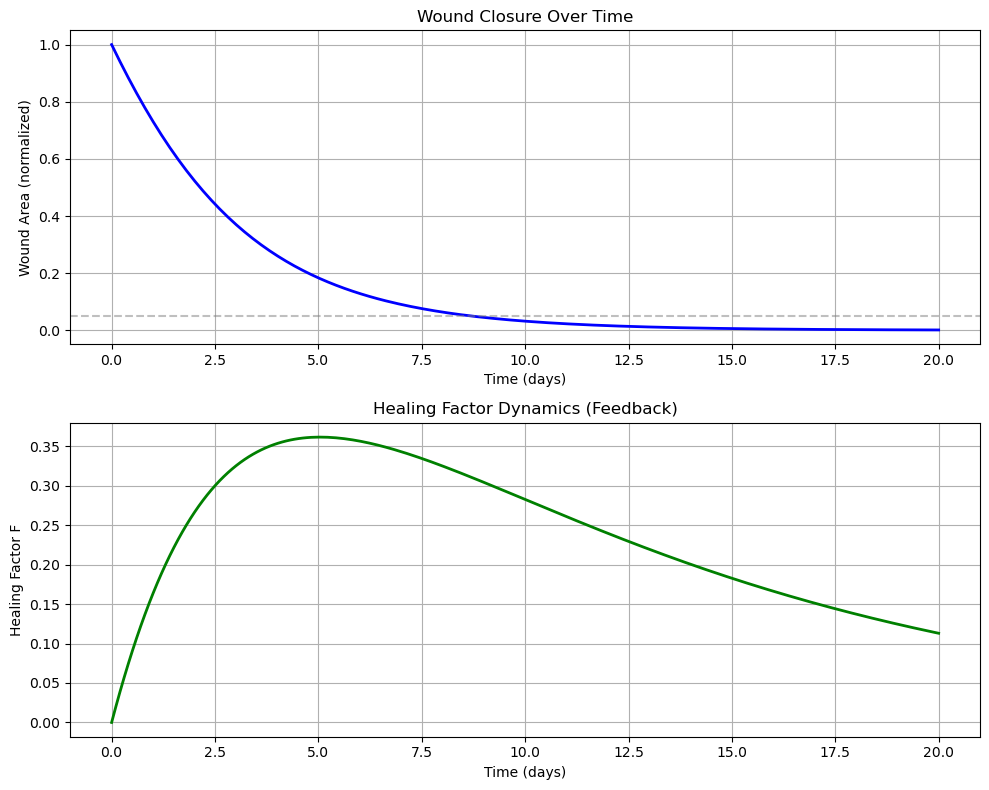

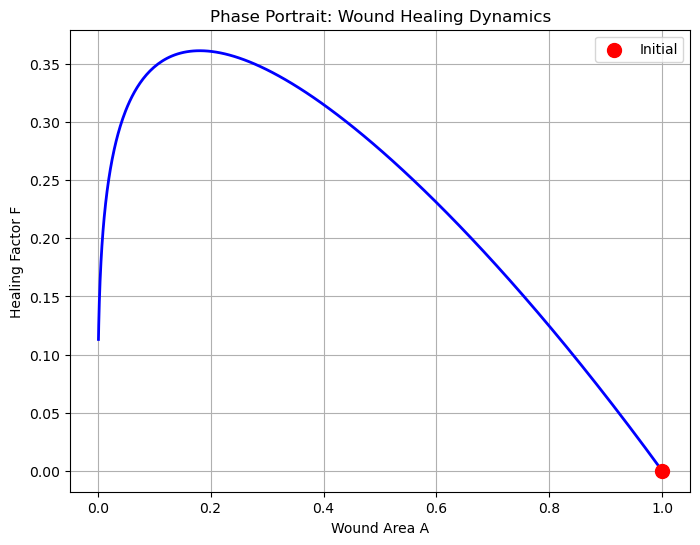

In [1]:
# Wound Healing Cybernetics Tutorial
# Based on feedback control dynamics

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from dataclasses import dataclass

@dataclass
class WoundParams:
    """Parameters for wound healing model"""
    k: float      # Base healing rate (1/day)
    alpha: float  # Feedback gain
    beta: float   # Wound-stimulated recruitment
    gamma: float  # Healing factor decay

def wound_model(state, t, params: WoundParams):
    """ODE system: state = [A, F], A=wound area, F=healing factor"""
    A, F = state
    dAdt = -params.k * A * (1 + params.alpha * F)
    dFdt = params.beta * A - params.gamma * F
    return [dAdt, dFdt]

# Parameters (normalized units, A in cm^2, F dimensionless)
params = WoundParams(k=0.3, alpha=0.5, beta=0.2, gamma=0.1)

# Initial conditions: wound area A0=1, no healing factor
A0, F0 = 1.0, 0.0
t = np.linspace(0, 20, 200)

sol = odeint(wound_model, [A0, F0], t, args=(params,))
A_sol, F_sol = sol[:, 0], sol[:, 1]

# Plot wound closure over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(t, A_sol, 'b-', linewidth=2)
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Wound Area (normalized)')
ax1.set_title('Wound Closure Over Time')
ax1.grid(True)
ax1.axhline(y=0.05, color='gray', linestyle='--', alpha=0.5, label='~95% healed')

ax2.plot(t, F_sol, 'g-', linewidth=2)
ax2.set_xlabel('Time (days)')
ax2.set_ylabel('Healing Factor F')
ax2.set_title('Healing Factor Dynamics (Feedback)')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Phase portrait: A vs F
plt.figure(figsize=(8, 6))
plt.plot(A_sol, F_sol, 'b-', linewidth=2)
plt.scatter([A0], [F0], c='red', s=100, zorder=5, label='Initial')
plt.xlabel('Wound Area A')
plt.ylabel('Healing Factor F')
plt.title('Phase Portrait: Wound Healing Dynamics')
plt.legend()
plt.grid(True)
plt.show()

## Interpretation of Wound Healing Dynamics

### Wound Closure (Top Plot)
- Wound area decreases exponentially over time
- The feedback term $(1 + \alpha F)$ accelerates healing when $F$ is elevated
- Healing factor initially rises (wound stimulates it) then decays as wound closes

### Healing Factor (Middle Plot)
- $F$ peaks early when wound is large (stimulus is maximal)
- As wound shrinks, stimulus decreases and $F$ decays
- This illustrates the **negative feedback** structure: wound → healing → wound shrinks → stimulus ↓

### Phase Portrait (Bottom Plot)
- Trajectory in $(A, F)$ space shows the system evolving toward the fixed point $(0, 0)$
- The loop shape reflects the transient buildup of healing factors before wound closure dominates

### Extensions
- **Chronic wounds**: Could be modeled by reduced $k$ or $\beta$ (impaired healing response)
- **Bioelectronic control**: External input could modulate $k$ or $F$ based on sensor feedback
- **Spatial models**: Add diffusion terms for cell migration and growth factor gradients